# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Risk Management - Exercise 0: Discount Factors Bootstrap

In [14]:
# Importing the libraries

import os
#import pickle
import numpy as np
import pandas as pd

import datetime as dt

from utilities.date_functions import year_frac_act_x, year_frac_30e_360, business_date_offset
from utilities.ex0_utilities import bootstrap, from_discount_factors_to_zero_rates

#### Useful functions

In [15]:
# to move dates
test_t = dt.date(2025,1,1)      #pd.Timestamp('2025-01-01')   you can use both date datatype from datetime library and pandas library
test_t_shifted = business_date_offset(test_t, year_offset=1,month_offset=4,day_offset=-10)
print(test_t_shifted)

2026-04-21


In [16]:
# to compute year fractions
yf_360 = year_frac_act_x(test_t, test_t_shifted, 360)
yf_365 = year_frac_act_x(test_t, test_t_shifted, 365)
yf_30_360 = year_frac_30e_360(test_t, test_t_shifted)
print(f"{yf_360:.4}, {yf_365:.4}, {yf_30_360:.4}")

1.319, 1.301, 1.306


#### Import data and convert when needed

In [17]:
dt = pd.read_csv('mkt_data/dt.csv',
                index_col = 'Market',
                usecols = ['Market','TARGET'],
                converters = {'TARGET':pd.to_datetime})
settlement_date  = dt.TARGET['Settlement']

In [18]:
settlement_date 

Timestamp('2008-02-19 00:00:00')

In [19]:
depo_converter = lambda x: float(x)/100.0  # apply the correct one

df_depos = pd.read_csv('mkt_data/depos.csv', 
                   index_col ='Depos',
                   usecols = ['Depos','ASK','BID'], 
                   converters={'Depos':pd.to_datetime,'BID':depo_converter,'ASK':depo_converter})

In [20]:
future_converter = lambda x: float(x) # apply the correct one

futures = pd.read_csv('mkt_data/futures.csv',
                      index_col ='Futures',
                      usecols = ['Futures','ASK','BID'],
                      converters={'Futures':pd.to_datetime,'BID':future_converter,'ASK':future_converter})
expiry = pd.read_csv('mkt_data/expiry.csv',
                     index_col = 'Futures',
                     usecols =['Futures', 'Settle', 'Expiry'], 
                     converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
df_futures = futures.join(expiry)

In [21]:
df_futures

,BID,ASK,Settle,Expiry
Futures,,,,
2008-03-17,95.680,95.685,2008-03-19,2008-06-19
2008-06-16,96.065,96.070,2008-06-18,2008-09-18
2008-09-15,96.370,96.375,2008-09-17,2008-12-17
2008-12-15,96.525,96.530,2008-12-17,2009-03-17
2009-03-16,96.605,96.610,2009-03-18,2009-06-18
2009-06-15,96.570,96.580,2009-06-17,2009-09-17
2009-09-14,96.490,96.495,2009-09-16,2009-12-16
2009-12-14,96.365,96.375,2009-12-16,2010-03-16
2010-03-15,96.275,96.285,2010-03-17,2010-06-17


In [22]:
swap_converter = lambda x: float(x) # apply the correct one

df_swaps = pd.read_csv('mkt_data/swaps.csv',
                    index_col = 'Swaps',
                    usecols = ['Swaps','BID','ASK'],
                    converters={'Swaps':pd.to_datetime,'BID':swap_converter,'ASK':swap_converter})



In [23]:
rows = [0,1,-1]
print(df_depos.iloc[rows],'\n', df_futures.iloc[rows], '\n', df_swaps.iloc[rows])
# check in the import part what has to be changed

               BID     ASK
Depos                     
2008-02-20  0.0399  0.0403
2008-02-26  0.0405  0.0409
2009-02-19  0.0429  0.0435 
                BID     ASK     Settle     Expiry
Futures                                         
2008-03-17  95.680  95.685 2008-03-19 2008-06-19
2008-06-16  96.065  96.070 2008-06-18 2008-09-18
2010-03-15  96.275  96.285 2010-03-17 2010-06-17 
               BID    ASK
Swaps                   
2009-02-19  4.120  4.140
2010-02-19  3.861  3.882
2058-02-19  4.647  4.687


#### Bootstrap

In [24]:
# Storing the data in a dictionary
#market_data = dict()
#market_data["reference_date"] = settlement_date
#market_data["depo"] = df_depos
#market_data["futures"] = df_futures
#market_data["swaps"] = df_swaps
#pickle.dump(market_data, open("market_data.p", "wb"))

# Bootstrap
discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)

/Users/gabrieldelhay/Desktop/COURSES/POLIMI/FINANCIAL ENGINEERING/git repo/FinEng_group4/assignement0/utilities/ex0_utilities.py:80: RuntimeWarning: invalid value encountered in scalar divide
  zero_rates = [-np.log(df) / yf for df, yf in zip(discount_factors, T)]


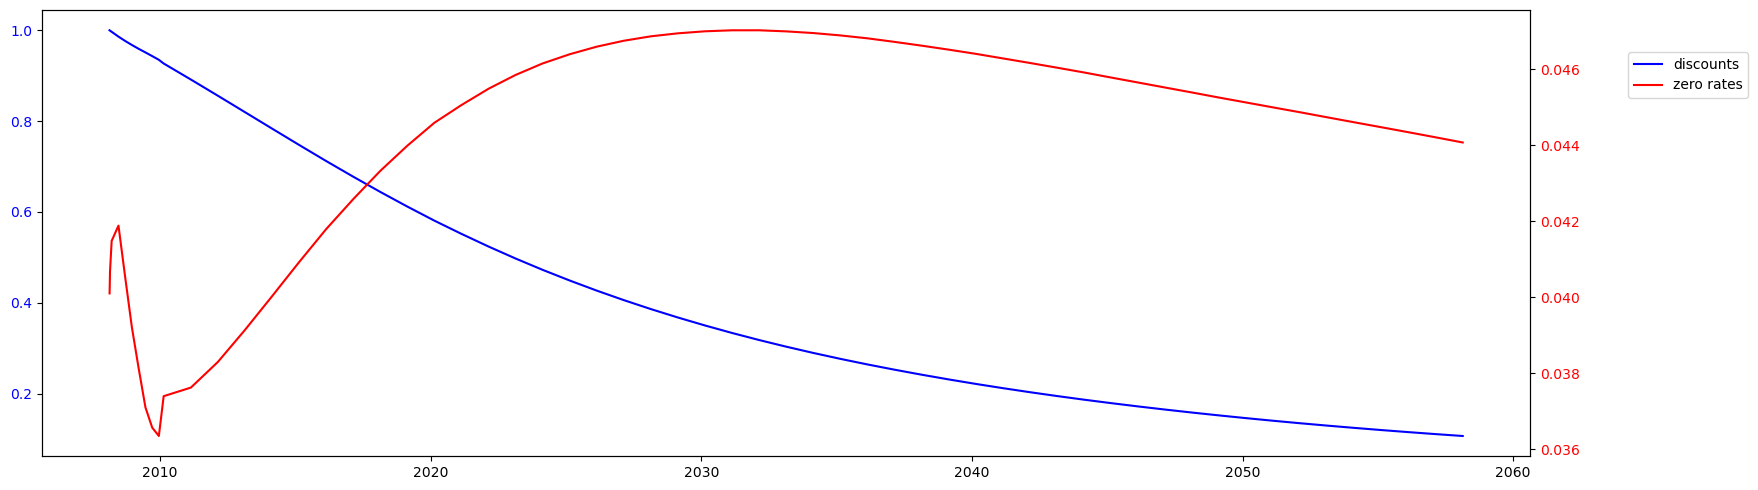

In [25]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(discount_factors.index, discount_factors.values, 'b-', label='discounts')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot( zero_rates.index, zero_rates.values, 'r-', label='zero rates')
ax2.tick_params(axis='y', labelcolor='r')

# Optional: Add legends
fig.legend( bbox_to_anchor=(1.1, 0.9))

plt.tight_layout()
plt.show()

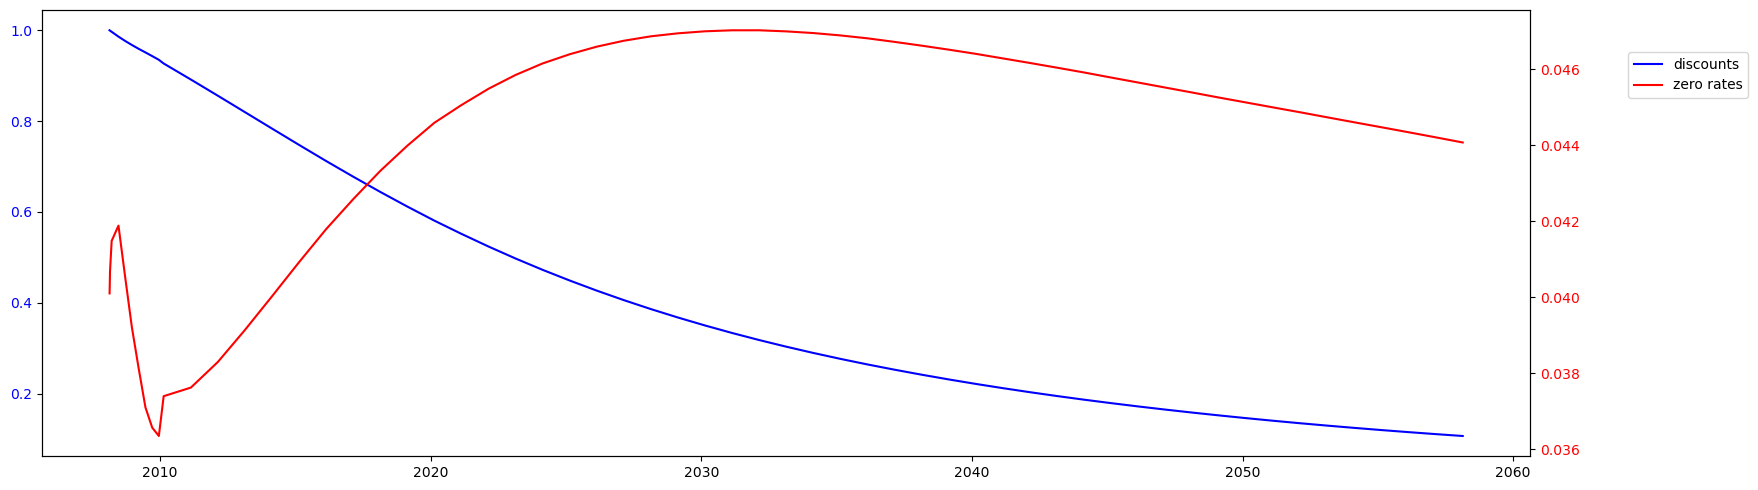

In [26]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(discount_factors.index, discount_factors.values, 'b-', label='discounts')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(discount_factors.index[1:], zero_rates, 'r-', label='zero rates')
ax2.tick_params(axis='y', labelcolor='r')

# Optional: Add legends
fig.legend( bbox_to_anchor=(1.1, 0.9))

plt.tight_layout()
plt.show()


